In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../House_Data/train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Check missing values
print("Missing Values (Top 15):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15))

print("\nBasic Statistics:")
print(df['SalePrice'].describe())

Missing Values (Top 15):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
dtype: int64

Basic Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


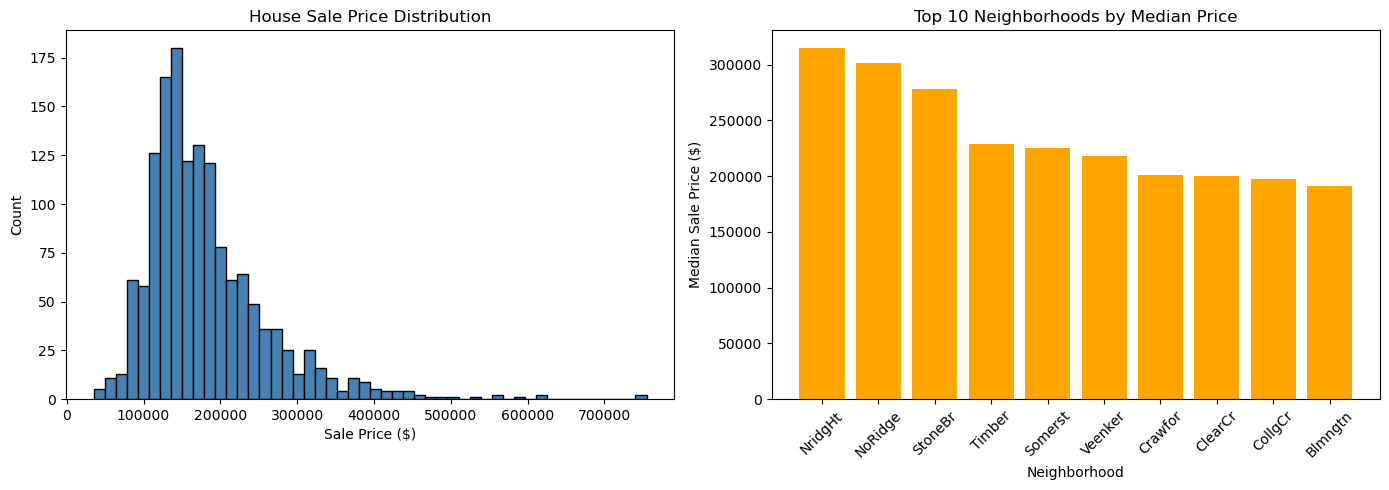

In [3]:
# Visualize Sale Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Sale Price Distribution
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('House Sale Price Distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

# Chart 2 — Sale Price by Neighborhood (Top 10)
top_neighborhoods = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
axes[1].bar(top_neighborhoods.index, top_neighborhoods.values, color='orange')
axes[1].set_title('Top 10 Neighborhoods by Median Price')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('Median Sale Price ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Top 10 Features Most Correlated with Sale Price:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


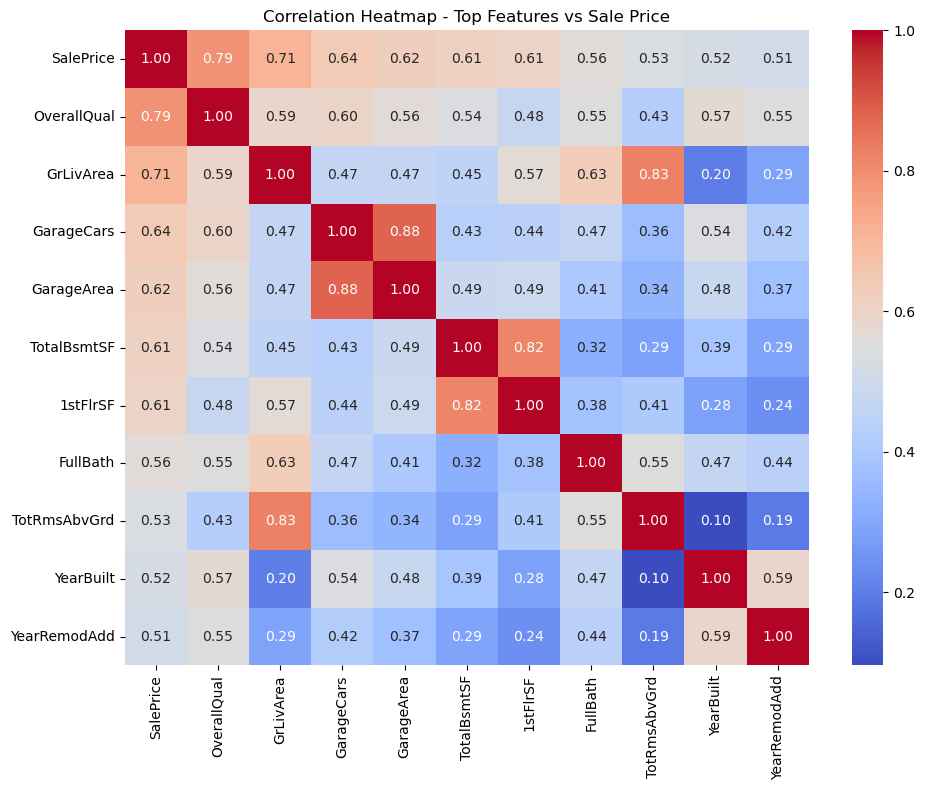

In [4]:
# Top features correlated with Sale Price
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("Top 10 Features Most Correlated with Sale Price:")
print(correlation.head(11))

# Heatmap of top features
top_features = correlation.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top Features vs Sale Price')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.linear_model import Ridge

# Select top features (Feature Selection)
features = ['OverallQual', 'GrLivArea', 'GarageCars', 
            'GarageArea', 'TotalBsmtSF', '1stFlrSF', 
            'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']

# Prepare data
X = df[features].copy()
y = df['SalePrice'].copy()

# 1. Handle missing values properly (Impute with Median instead of 0)
for col in features:
    X[col] = X[col].fillna(X[col].median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

# Train Ridge Regression Model
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("\nModel Performance:")
print(f"Linear Regression - R2 Score: {lr_r2} | RMSE: ${lr_rmse}")
print(f"Ridge Regression  - R2 Score: {ridge_r2} | RMSE: ${ridge_rmse}")
print(f"Random Forest     - R2 Score: {rf_r2} | RMSE: ${rf_rmse}")


Training set size: (1168, 10)
Testing set size: (292, 10)

Model Performance:
Linear Regression - R2 Score: 0.7968483304281092 | RMSE: $39474.54338116013
Ridge Regression  - R2 Score: 0.7969833124280244 | RMSE: $39461.42697850199
Random Forest     - R2 Score: 0.8856242714556324 | RMSE: $29619.236116415683
